<a href="https://colab.research.google.com/github/uznainrashid/DataScience/blob/main/DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for Machine Learning (Scientific Toolkit)
import sklearn

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
full_data = pd.read_csv("/content/titanic.csv")
print("Data Shape:", full_data.shape)

Data Shape: (891, 12)


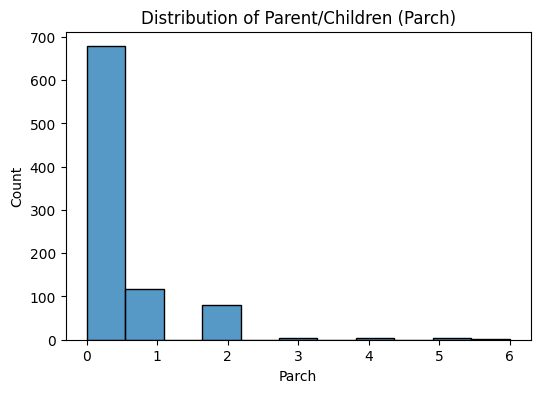

In [ ]:
# full_data.head()
plt.figure(figsize=(6,4))
sns.histplot(full_data['Parch'])
plt.title("Distribution of Parent/Children (Parch)")
plt.show()


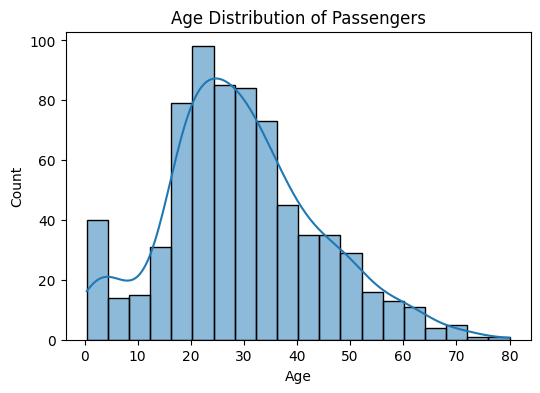

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(full_data['Age'], kde=True) # Video mein displot/kdeplot use hua tha
plt.title("Age Distribution of Passengers")
plt.show()

<Figure size 600x400 with 0 Axes>

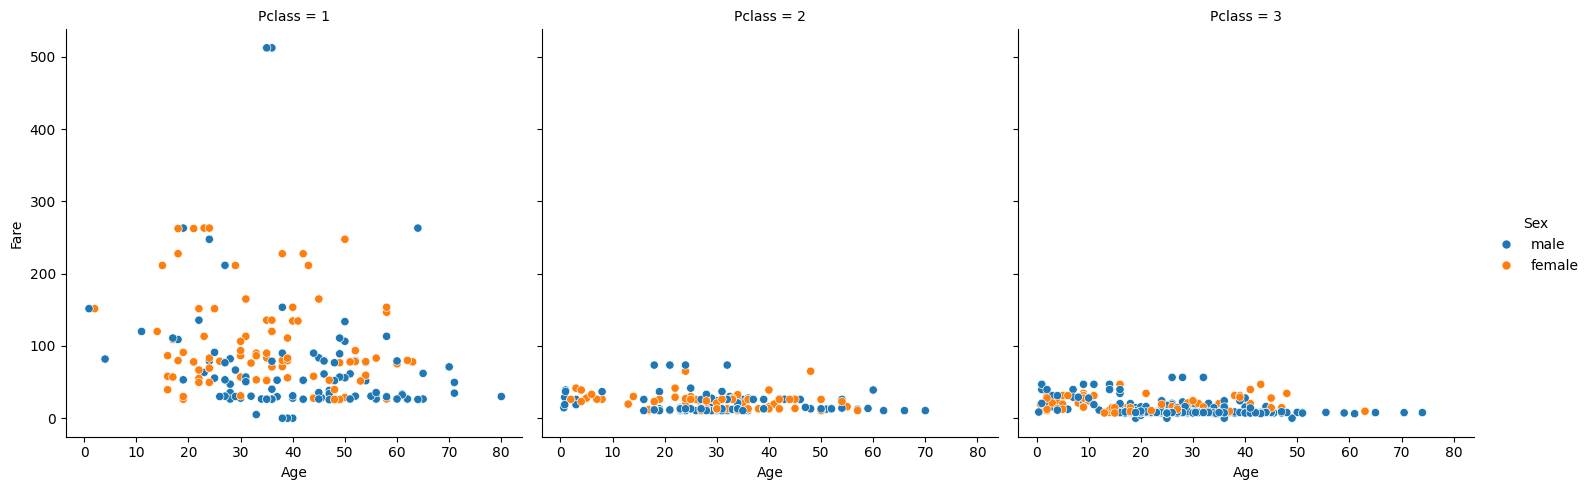

In [ ]:
# 3. Relational Plot (Age vs Fare with Pclass split & Sex hue)
sns.relplot(x='Age', y='Fare', col='Pclass', hue='Sex', data=full_data, kind='scatter')
plt.show()

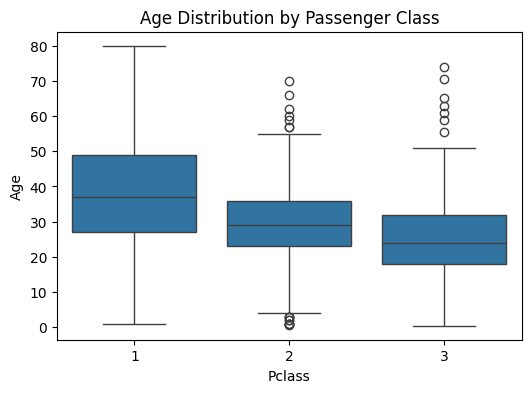

In [ ]:
# 4. Box Plot (Pclass vs Age - Outliers check karne k liye)
plt.figure(figsize=(6,4))
sns.boxplot(x='Pclass', y='Age', data=full_data)
plt.title("Age Distribution by Passenger Class")
plt.show()

In [ ]:
print(full_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


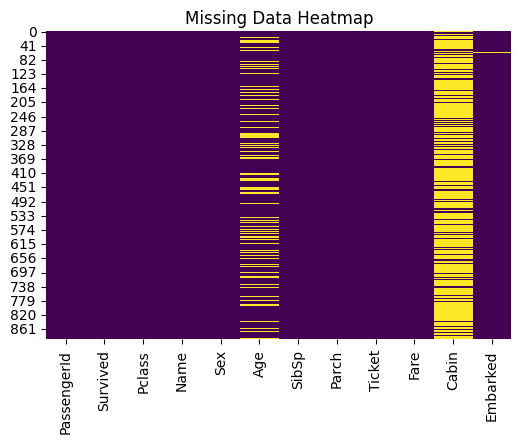

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(full_data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()
#

In [ ]:
full_data.drop('Cabin', axis=1,inplace=True)
print(full_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None


In [ ]:
# Baki missing values wali rows ko remove karna
full_data.dropna(inplace=True)

print("Shape after dropping null values:", full_data.shape)

Shape after dropping null values: (712, 11)


In [ ]:
# Irrelevant columns drop karna (Data Reduction)
full_data.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

KeyError: "['Name', 'Ticket', 'PassengerId'] not found in axis"

In [ ]:
print(full_data.select_dtypes(include=['object']).columns)

# One-Hot Encoding (pd.get_dummies) to make symbols/binary numbers
gender_dummies = pd.get_dummies(full_data['Sex'], drop_first=True)
embarked_dummies = pd.get_dummies(full_data['Embarked'], drop_first=True)

# Naye dummy features ko main data k sath connect (concat) karna
full_data = pd.concat([full_data, gender_dummies, embarked_dummies], axis=1)

# Puranay string columns ko drop karna
full_data.drop(['Sex', 'Embarked'], axis=1, inplace=True)

# Final clean data checking (Pure numeric data ready for ML model)
print("\n--- Final Dataset Summary ---")
print(full_data.describe())
full_data.head()

Index(['Sex', 'Embarked'], dtype='object')

--- Final Dataset Summary ---
         Survived      Pclass         Age       SibSp       Parch        Fare
count  712.000000  712.000000  712.000000  712.000000  712.000000  712.000000
mean     0.404494    2.240169   29.642093    0.514045    0.432584   34.567251
std      0.491139    0.836854   14.492933    0.930692    0.854181   52.938648
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    1.000000   20.000000    0.000000    0.000000    8.050000
50%      0.000000    2.000000   28.000000    0.000000    0.000000   15.645850
75%      1.000000    3.000000   38.000000    1.000000    1.000000   33.000000
max      1.000000    3.000000   80.000000    5.000000    6.000000  512.329200


,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
